# CNN-projekt: Bildklassificering med CIFAR-10

**Dataset:** CIFAR-10 — 60 000 RGB-bilder (32×32 px), 10 klasser  
**Ramverk:** TensorFlow 2.x / Keras  
**Mål:** Träna ett CNN som klassar bilder och utvärdera om justeringar krävs

**Klasser:** airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

---
## 1. Imports och konfiguration

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import datasets, models, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU tillgänglig: {len(tf.config.list_physical_devices('GPU')) > 0}")

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

TensorFlow version: 2.21.0
GPU tillgänglig: False


---
## 2. Ladda och utforska data (EDA)

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

y_train = y_train.flatten()
y_test  = y_test.flatten()

print(f"Träningsset:  {X_train.shape}  labels: {y_train.shape}")
print(f"Testset:      {X_test.shape}   labels: {y_test.shape}")
print(f"Pixelintervall (rådata): [{X_train.min()}, {X_train.max()}]")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
Träningsset:  (50000, 32, 32, 3)  labels: (50000,)
Testset:      (10000, 32, 32, 3)   labels: (10000,)
Pixelintervall (rådata): [0, 255]


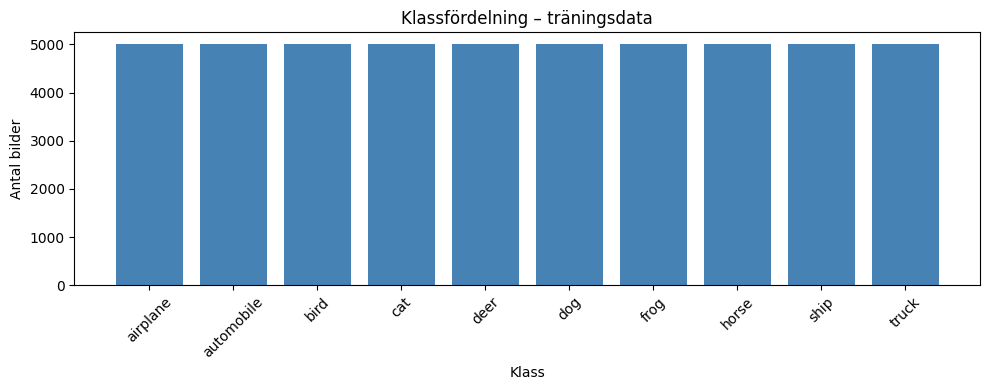

In [3]:
# Klassfördelning
fig, ax = plt.subplots(figsize=(10, 4))
unique, counts = np.unique(y_train, return_counts=True)
ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
ax.set_title('Klassfördelning – träningsdata')
ax.set_xlabel('Klass')
ax.set_ylabel('Antal bilder')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

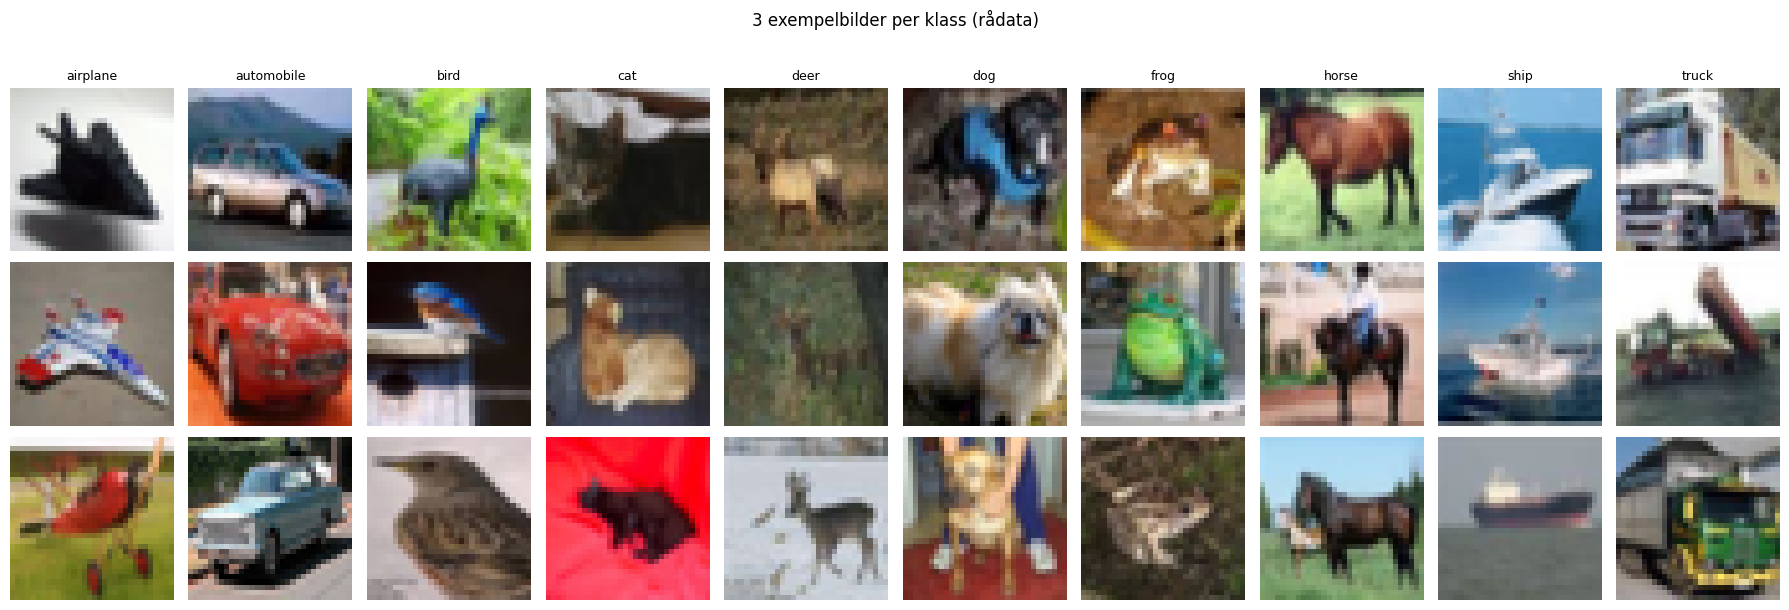

In [4]:
# Visa exempelbilder
fig, axes = plt.subplots(3, 10, figsize=(18, 6))
for cls_idx in range(10):
    idxs = np.where(y_train == cls_idx)[0][:3]
    for row, img_idx in enumerate(idxs):
        axes[row, cls_idx].imshow(X_train[img_idx])
        axes[row, cls_idx].axis('off')
        if row == 0:
            axes[row, cls_idx].set_title(CLASS_NAMES[cls_idx], fontsize=9)
plt.suptitle('3 exempelbilder per klass (rådata)', y=1.02)
plt.tight_layout()
plt.show()

---
## 3. Förbehandling

In [5]:
# Normalisera pixlar till [0, 1]
X_train_norm = X_train / 255.0
X_test_norm  = X_test  / 255.0

print(f"Pixelintervall (normaliserat): [{X_train_norm.min():.1f}, {X_train_norm.max():.1f}]")
print(f"Bildform: {X_train_norm.shape[1:]}  (höjd × bredd × kanaler)")

Pixelintervall (normaliserat): [0.0, 1.0]
Bildform: (32, 32, 3)  (höjd × bredd × kanaler)


---
## 4. Modell 1 – Baseline CNN

In [6]:
def build_baseline_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_v1 = build_baseline_model()
model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop_v1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_v1 = model_v1.fit(
    X_train_norm, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop_v1],
    verbose=1
)

Epoch 1/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.4489 - loss: 1.5185 - val_accuracy: 0.5738 - val_loss: 1.1990
Epoch 2/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 22ms/step - accuracy: 0.6166 - loss: 1.0873 - val_accuracy: 0.6467 - val_loss: 0.9996
Epoch 3/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.6825 - loss: 0.9075 - val_accuracy: 0.6852 - val_loss: 0.9129
Epoch 4/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.7262 - loss: 0.7877 - val_accuracy: 0.7095 - val_loss: 0.8490
Epoch 5/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7596 - loss: 0.6957 - val_accuracy: 0.7106 - val_loss: 0.8630
Epoch 6/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.7851 - loss: 0.6200 - val_accuracy: 0.7252 - val_loss: 0.8355
Epoch 7/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 24ms/step - accuracy: 0.8080 - loss: 0.5568 - val_accuracy: 0.7290 - val_loss: 0.8397
Epoch 8/30
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.8280 - loss: 0.5018 - 

---
## 5. Utvärdering – Modell 1

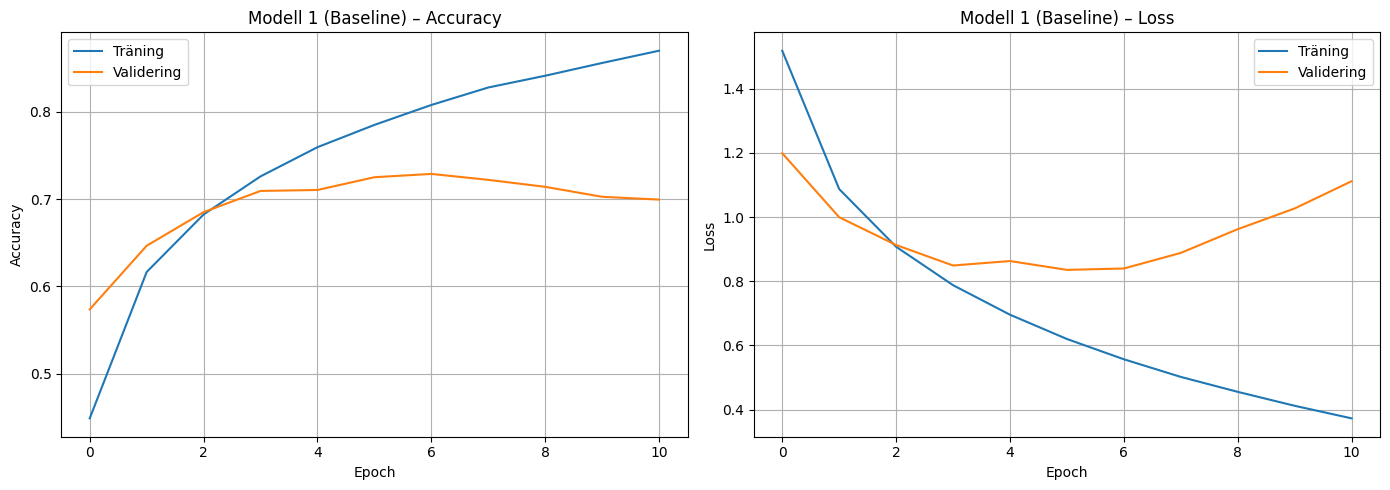

In [8]:
def plot_history(history, title='Träningshistorik'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['accuracy'],     label='Träning')
    ax1.plot(history.history['val_accuracy'], label='Validering')
    ax1.set_title(f'{title} – Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    ax2.plot(history.history['loss'],     label='Träning')
    ax2.plot(history.history['val_loss'], label='Validering')
    ax2.set_title(f'{title} – Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_v1, 'Modell 1 (Baseline)')

Modell 1 (Baseline) — Testaccuracy: 0.7117 | Testloss: 0.8530

Classification Report:
              precision    recall  f1-score   support

    airplane       0.72      0.74      0.73      1000
  automobile       0.86      0.81      0.84      1000
        bird       0.59      0.59      0.59      1000
         cat       0.53      0.52      0.53      1000
        deer       0.77      0.58      0.66      1000
         dog       0.68      0.55      0.61      1000
        frog       0.71      0.85      0.77      1000
       horse       0.73      0.80      0.77      1000
        ship       0.73      0.88      0.80      1000
       truck       0.79      0.80      0.80      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



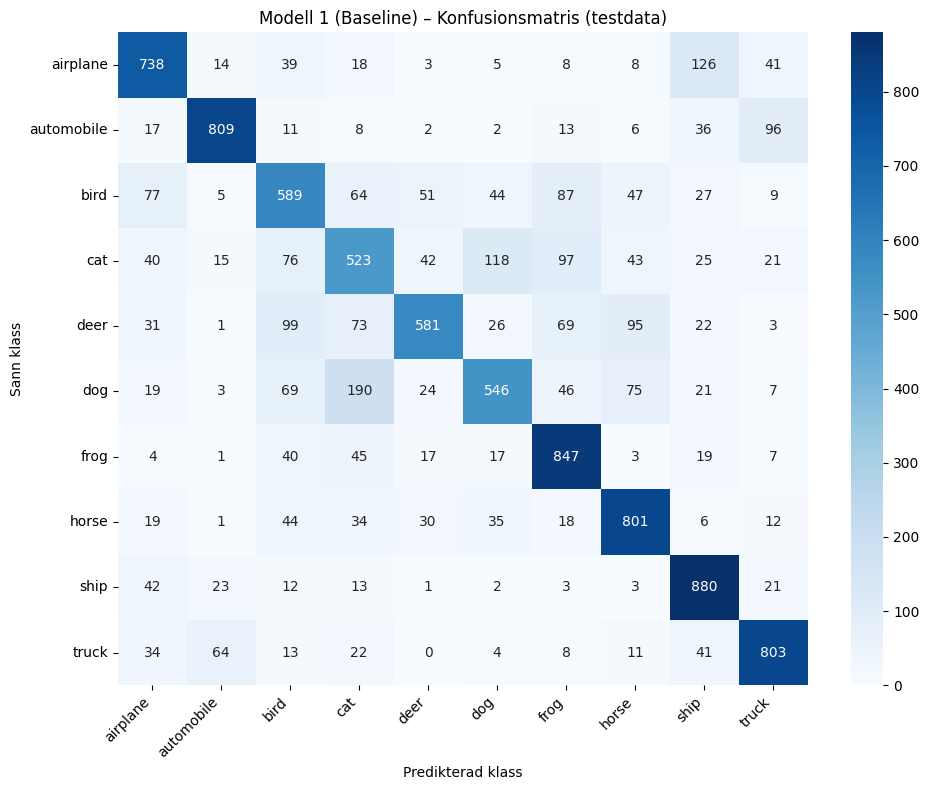

In [9]:
def evaluate_model(model, X_test, y_test, model_name='Modell'):
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"{model_name} — Testaccuracy: {acc:.4f} | Testloss: {loss:.4f}\n")

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)

    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f'{model_name} – Konfusionsmatris (testdata)')
    ax.set_xlabel('Predikterad klass')
    ax.set_ylabel('Sann klass')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    return acc, y_pred

acc_v1, y_pred_v1 = evaluate_model(model_v1, X_test_norm, y_test, 'Modell 1 (Baseline)')

---
## 6. Analys – Behöver modellen justeras?

### Vad visar träningskurvorna?

När vi tittar på graferna ser vi ett tydligt mönster:

- **Träningsnoggrannheten** steg kontinuerligt och nådde ~87% vid epoch 11
- **Valideringsnoggrannheten** planade ut runt ~73% redan vid epoch 6–7, och började sedan sjunka
- **Valideringsförlusten** började stiga efter epoch 6, medan träningsförlusten fortsatte nedåt

Det här kallas **overfitting (överanpassning)** — modellen lär sig träningsdatan för bra, nästan utantill, och tappar förmågan att generalisera till bilder den aldrig sett. Gapet mellan 87% (träning) och 71% (test) på ~16 procentenheter bekräftar detta.

EarlyStopping stoppade träningen vid epoch 11 och återställde de bästa vikterna från epoch 6, vilket gav oss ett **testresultat på 71.17%**.

### Vad klarar modellen bra och dåligt?

| Klass | F1-score | Kommentar |
|-------|----------|-----------|
| automobile | 0.84 | Tydlig form, lätt att känna igen |
| ship | 0.80 | Stark kontrast mot bakgrund (hav) |
| truck | 0.80 | Lik bil men tydlig storlek |
| **cat** | **0.53** | Svårast — förväxlas med dog |
| **bird** | **0.59** | Förväxlas med airplane |
| **dog** | **0.61** | Förväxlas med cat |

Katt och hund är de svåraste klasserna — inte konstigt, de ser faktiskt lika ut. Samma sak med fågel och flygplan som båda kan ha liknande silhuetter mot himlen.

### Slutsats — behöver modellen justeras?

**Ja.** Overfitting är tydlig och testaccuracy på 71% har förbättringspotential. Vi går vidare med Modell 2 där vi introducerar:

- **Dropout** — stänger slumpmässigt av neuroner under träning för att tvinga modellen att lära sig mer robusta mönster
- **Data Augmentation** — skapar varianter av träningsbilderna (roterade, speglade etc.) så att modellen inte kan lära sig dem utantill
- **Dubbla Conv-lager per block** — ger nätverket mer kapacitet att fånga komplexa mönster

---
## 7. Modell 2 – Förbättrad CNN med Dropout och Data Augmentation

In [10]:
# Data augmentation för att minska overfitting
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(X_train_norm)

# Validering augmenteras INTE – bara normaliseras
val_split = 0.2
val_size  = int(len(X_train_norm) * val_split)
X_val, y_val       = X_train_norm[:val_size],  y_train[:val_size]
X_tr2, y_tr2       = X_train_norm[val_size:],  y_train[val_size:]

train_gen = datagen.flow(X_tr2, y_tr2, batch_size=64, seed=SEED)
print(f"Träning: {X_tr2.shape[0]} bilder | Validering: {X_val.shape[0]} bilder")

Träning: 40000 bilder | Validering: 10000 bilder


In [11]:
def build_improved_model():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_v2 = build_improved_model()
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 666,538 (2.54 MB)

 Trainable params: 666,538 (2.54 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop_v2 = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

steps_per_epoch = len(X_tr2) // 64

history_v2 = model_v2.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    epochs=50,
    validation_data=(X_val, y_val),
    callbacks=[early_stop_v2],
    verbose=1
)

Epoch 1/50
275/625 ━━━━━━━━━━━━━━━━━━━━ 15s 45ms/step - accuracy: 0.1954 - loss: 2.1301

---
## 8. Utvärdering – Modell 2

In [ ]:
plot_history(history_v2, 'Modell 2 (Förbättrad + Augmentering)')
acc_v2, y_pred_v2 = evaluate_model(model_v2, X_test_norm, y_test, 'Modell 2 (Förbättrad)')

---
## 9. Jämförelse av modeller

In [ ]:
print("=" * 40)
print(f"{'Modell':<25} {'Test Accuracy':>15}")
print("-" * 40)
print(f"{'Modell 1 (Baseline)':<25} {acc_v1:>14.4f}")
print(f"{'Modell 2 (Förbättrad)':<25} {acc_v2:>14.4f}")
print("=" * 40)

In [ ]:
# Visualisera felklassificerade bilder
def show_misclassified(X_test, y_test, y_pred, class_names, n=10):
    wrong = np.where(y_pred != y_test)[0]
    sample = wrong[:n]
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    for ax, idx in zip(axes.flat, sample):
        ax.imshow(X_test[idx])
        ax.set_title(f"Sant: {class_names[y_test[idx]]}\nPred: {class_names[y_pred[idx]]}",
                     fontsize=8, color='red')
        ax.axis('off')
    plt.suptitle('Felklassificerade bilder – Modell 2', fontsize=12)
    plt.tight_layout()
    plt.show()

show_misclassified(X_test_norm, y_test, y_pred_v2, CLASS_NAMES)

---
## 10. Slutsatser och databerättelse

> **Fyll i här med era faktiska resultat:**
>
> ### Vad vi gjort
> - Tränat ett baseline CNN och ett förbättrat CNN på CIFAR-10 (60 000 RGB-bilder, 10 klasser)
>
> ### Vad vi observerade
> - Modell 1 uppnådde XX% testaccuracy. Tydliga tecken på [overfitting / underfitting]?
> - Modell 2 uppnådde XX% testaccuracy tack vare dropout och data augmentation
>
> ### Svåraste klasser
> - Katt (cat) och hund (dog) förväxlas ofta → visuellt lika
> - Fågel (bird) och flygplan (airplane) förväxlas ibland
>
> ### Justeringar som gjordes (och varför)
> - Lade till Dropout → minskade gapet mellan tränings- och valideringsnoggrannhet
> - Data augmentation → mer varierad träningsdata, bättre generalisering
> - Early Stopping → förhindrade överträning
>
> ### Möjliga framtida förbättringar
> - Batch Normalization
> - Transfer Learning (VGG16, ResNet50)
> - Learning rate scheduling